In [9]:
import numpy as np
import gymnasium as gym
import time
import matplotlib.cm as cm
import matplotlib.pyplot as plt
from pygame._sdl2.video import Window

def plot_q(Q):
    cmap_name = 'YlGn'
    cmap = cm.get_cmap(cmap_name) # Use the get_cmap function from cm
    Q_plot=Q.reshape(4,4,4)
    print(np.min(Q_plot),np.max(Q_plot))
    for x in range(4):
        for y in range(4):
            #0:LEFT 1:Down 2:right 3:up
            best=np.argmax(Q_plot[y,x])
            plt.arrow(x-.025, 5-y, -.1, .0, head_width=0.15,color='black')
            plt.arrow(x, 5-y-.025, 0, -.1, head_width=0.15,color='black')
            plt.arrow(x+.025, 5-y, .1, .0, head_width=0.15,color='black')
            plt.arrow(x, 5-y+.025, 0, .1, head_width=0.15,color='black')

            
            if best ==0:
                plt.arrow(x-.025, 5-y, -.1, .0, head_width=0.15,color='blue')
            elif best ==1:
                        plt.arrow(x, 5-y-.025, 0, -.1, head_width=0.15,color='blue')
            elif best==2:
                plt.arrow(x+.025, 5-y, .1, .0, head_width=0.15,color='blue')
            elif best ==3:
                plt.arrow(x, 5-y+.025, 0, .1, head_width=0.15,color='blue')
            
            
    plt.show()



def evaluate_greedy(Q, env_id="FrozenLake-v1", is_slippery=False, seed=123, render=True):
    render_mode = "human" if render else None
    env = gym.make(env_id, is_slippery=is_slippery, render_mode=render_mode)

    obs, _ = env.reset(seed=seed)
    raw_window=Window.from_display_module()
    raw_window.focus()
    done = False
    total_reward = 0.0
    steps = 0

    while not done:
        action = int(np.argmax(Q[obs]))
        obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        total_reward += reward
        steps += 1
        time.sleep(.05)
        print(action,obs)

    env.close()
    print(f"Eval finished | steps={steps} | total_reward={total_reward}")



In [10]:
def train_MC_learning(
    env_id="FrozenLake-v1",
    episodes=10_000,
    alpha=0.1,
    gamma=0.999,
    eps_start=0.05,
    eps_decay=0.9995,
    eps_end=0.01,
    is_slippery=False,
    seed=0,
):
    env = gym.make(env_id, is_slippery=is_slippery,max_episode_steps=100)
    rng = np.random.default_rng(seed)
    # Discrete spaces -> Q-table
    n_states = env.observation_space.n
    n_actions = env.action_space.n
    Q = np.random.uniform(size=(n_states, n_actions))
#    Q = np.random.uniform(size=(n_states, n_actions))

    epsilon = eps_start
    returns = []
    total_returns=[]
    for ep in range(episodes):
        obs, _ = env.reset(seed=seed + ep)
        done = False
        rewards=[]
        actions=[]
        states=[]
        while not done:
            # ε-greedy action selection
            if rng.random() < epsilon:
                action = env.action_space.sample()
            else:
                action = int(np.argmax(Q[obs]))

            next_obs, reward, terminated, truncated, _ = env.step(action)
            rewards.append(reward)
            states.append(obs)
            actions.append(action)            
            obs = next_obs
            done = terminated or truncated
        # Update after trail
        total_returns.append(sum(rewards))
        returns = []
        g = 0.0
        for r in reversed(rewards):
            g = r + gamma * g
            returns.append(g)
        returns.reverse()
        for s,a,r in zip(states,actions,rewards): 
            Q[s, a] += alpha * (g - Q[s, a])


        # Decay exploration
        epsilon = max(eps_end, epsilon * eps_decay)

        if (ep ) % 1000 == 0:
            plot_q(Q)
            avg = np.mean(total_returns[-1000:])
            print(f"Episode {ep+1:>6} | epsilon={epsilon:.3f} | avg_return(last 2000)={avg:.3f}")

    env.close()
    return Q

In [11]:
def train_q_learning(
    env_id="FrozenLake-v1",
    episodes=10_000,
    alpha=0.1,
    gamma=0.99,
    eps_start=1.0,
    eps_end=0.05,
    eps_decay=0.999999,
    is_slippery=False,
    seed=0,
):
    env = gym.make(env_id, is_slippery=is_slippery,max_episode_steps=100)
    rng = np.random.default_rng(seed)
    # Discrete spaces -> Q-table
    n_states = env.observation_space.n
    n_actions = env.action_space.n
    Q = np.random.uniform(size=(n_states, n_actions))

    epsilon = eps_start
    returns = []

    for ep in range(episodes):
        obs, _ = env.reset(seed=seed + ep)
        done = False
        total_reward = 0.0

        while not done:
            # ε-greedy action selection
            if rng.random() < epsilon:
                action = env.action_space.sample()
            else:
                action = int(np.argmax(Q[obs]))

            next_obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total_reward += reward

            # Q-learning target: r if terminal else r + γ max_a' Q(s', a')
            if done:
                target = reward
            else:
                target = reward + gamma * np.max(Q[next_obs])

            # Update
            Q[obs, action] += alpha * (target - Q[obs, action])

            obs = next_obs

        #  exploration
        epsilon = max(eps_end, epsilon * eps_decay)
        alpha=max(1e-4, alpha * eps_decay)
        returns.append(total_reward)

        if (ep ) % 1000 == 0:
            plot_q(Q)
            avg = np.mean(returns[-1000:])
            print(f"Episode {ep+1:>6} | epsilon={epsilon:.3f} | avg_return(last 2000)={avg:.3f}")

    env.close()
    return Q

0.006479939593692752 0.9665066720317724


/var/folders/53/qn2bqxzd489fdf7zn6smrbtw0000gn/T/ipykernel_50194/3325929490.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name) # Use the get_cmap function from cm


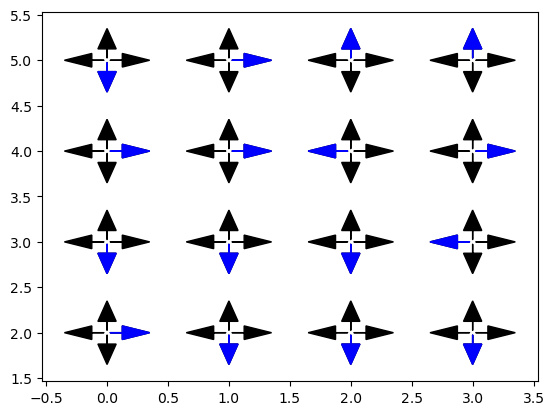

Episode      1 | epsilon=0.050 | avg_return(last 2000)=0.000
6.239601088348899e-11 0.9948399351108208


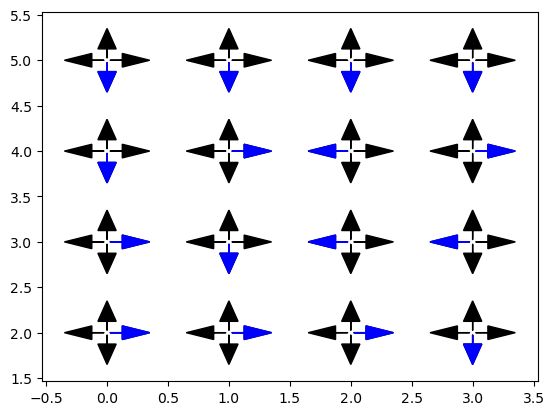

Episode   1001 | epsilon=0.030 | avg_return(last 2000)=0.607
4.606098620131624e-11 0.994863739153436


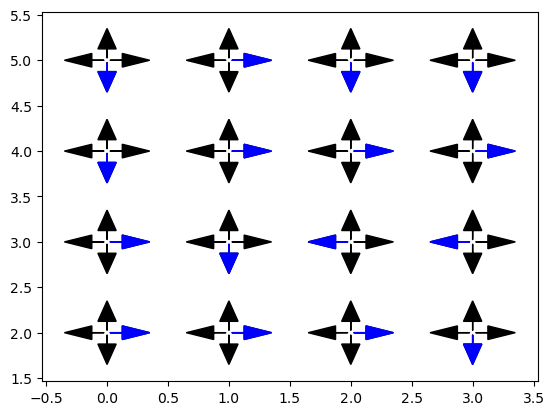

Episode   2001 | epsilon=0.018 | avg_return(last 2000)=0.972
3.357845894075954e-11 0.9949923583293728


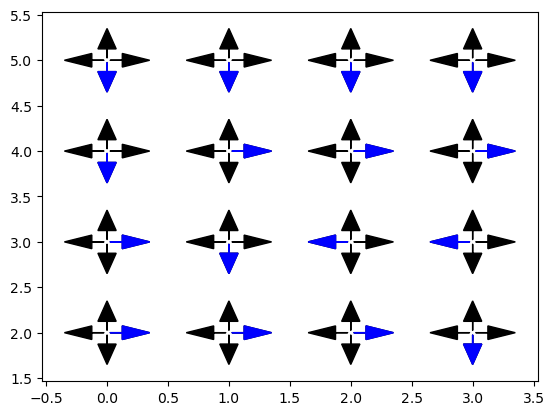

Episode   3001 | epsilon=0.011 | avg_return(last 2000)=0.981
3.0220613046683584e-11 0.994980168905541


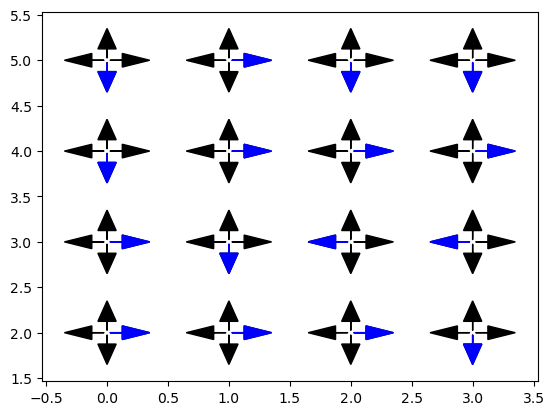

Episode   4001 | epsilon=0.010 | avg_return(last 2000)=0.982
2.2030826911032334e-11 0.995009807375481


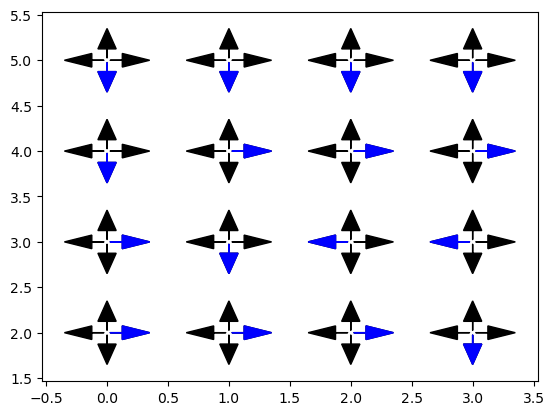

Episode   5001 | epsilon=0.010 | avg_return(last 2000)=0.976
2.2030826911032334e-11 0.995007904921727


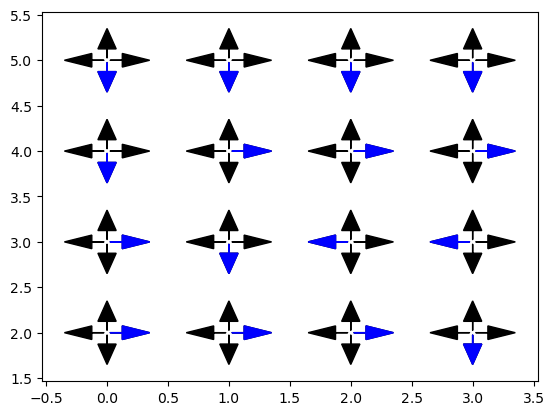

Episode   6001 | epsilon=0.010 | avg_return(last 2000)=0.993
1.606047281814257e-11 0.9949783923268355


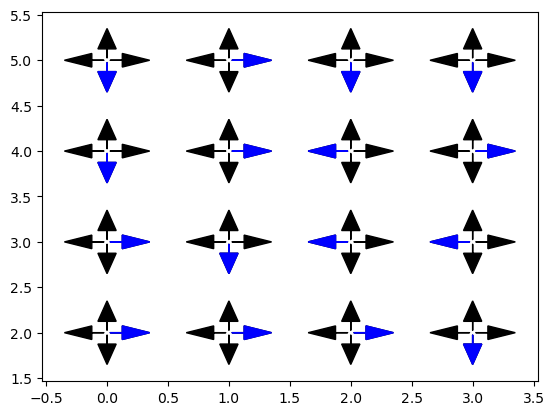

Episode   7001 | epsilon=0.010 | avg_return(last 2000)=0.988
5.72571660661022e-15 0.994810945317596


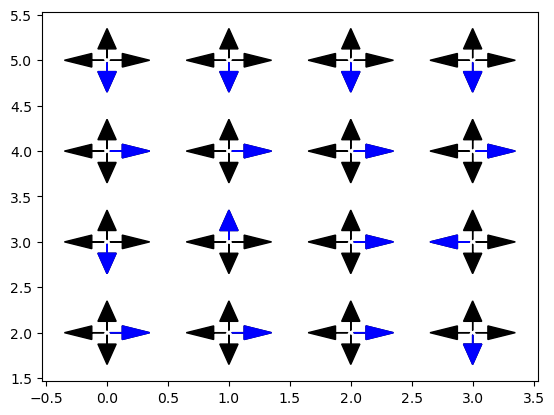

Episode   8001 | epsilon=0.010 | avg_return(last 2000)=0.863
1.5208304270545774e-19 0.9950099889810906


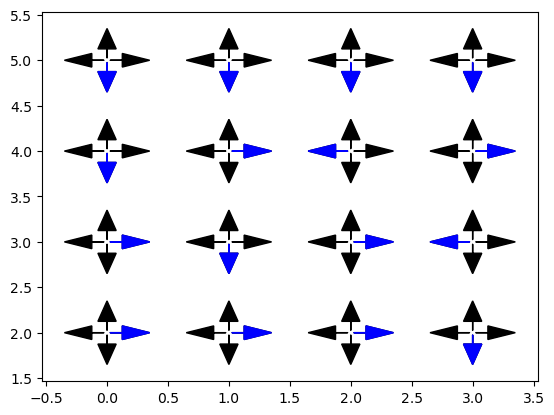

Episode   9001 | epsilon=0.010 | avg_return(last 2000)=0.781


In [12]:
slip=False
Q = train_MC_learning(is_slippery=slip)


In [13]:
evaluate_greedy(Q, is_slippery=slip)

2026-03-02 11:08:59.097 python[50194:15871819] +[IMKClient subclass]: chose IMKClient_Modern
2026-03-02 11:08:59.097 python[50194:15871819] +[IMKInputSession subclass]: chose IMKInputSession_Modern


1 4
1 8
2 9
1 13
2 14
2 15
Eval finished | steps=6 | total_reward=1.0


In [14]:
#env.reset()
#obs, reward, terminated, truncated, _ = env.step()
#print(obs)
#obs, reward, terminated, truncated, _ = env.step(1)
#print(obs)

0.018278064766368396 0.9955811012599667


/var/folders/53/qn2bqxzd489fdf7zn6smrbtw0000gn/T/ipykernel_50194/3325929490.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name) # Use the get_cmap function from cm


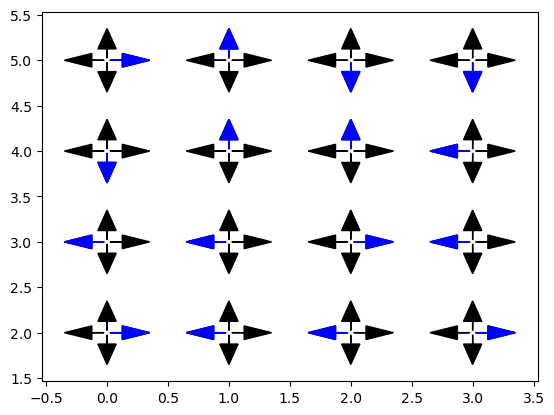

Episode      1 | epsilon=1.000 | avg_return(last 2000)=0.000
2.633239188715852e-16 0.9955811012599667


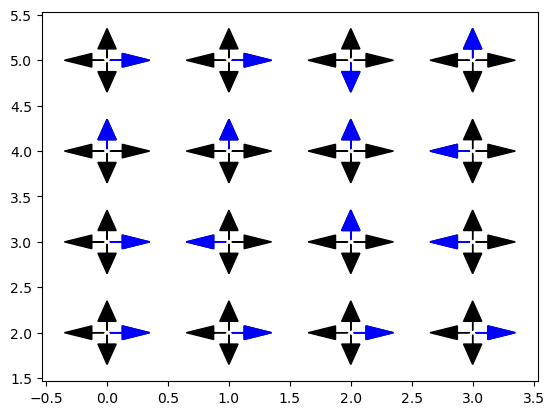

Episode   1001 | epsilon=0.999 | avg_return(last 2000)=0.019
1.3074528719476385e-31 0.9955811012599667


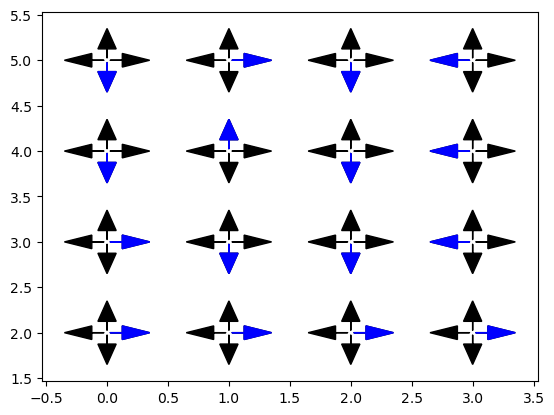

Episode   2001 | epsilon=0.998 | avg_return(last 2000)=0.015
1.1497618884192663e-45 0.9977092929393602


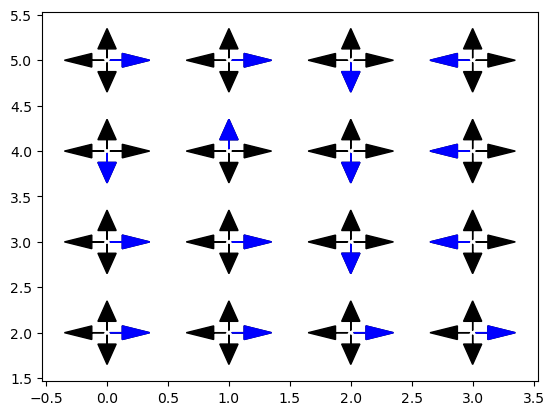

Episode   3001 | epsilon=0.997 | avg_return(last 2000)=0.017
1.5908819216320414e-59 0.9993500613417198


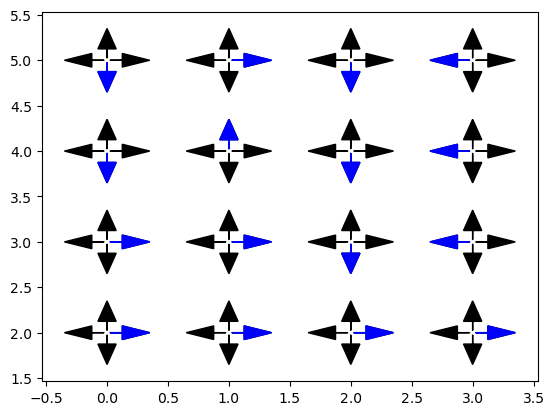

Episode   4001 | epsilon=0.996 | avg_return(last 2000)=0.012
4.273539504413466e-73 0.9997949080621474


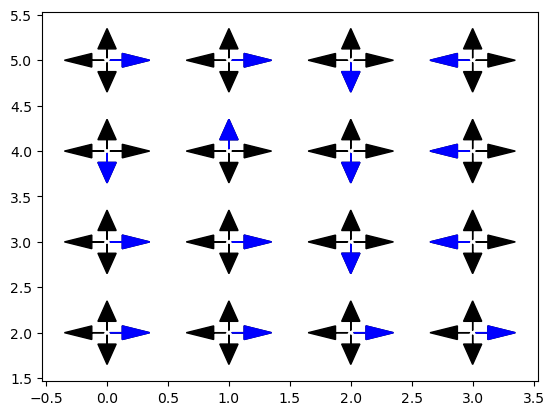

Episode   5001 | epsilon=0.995 | avg_return(last 2000)=0.011
9.59261595568093e-88 0.9999616246999291


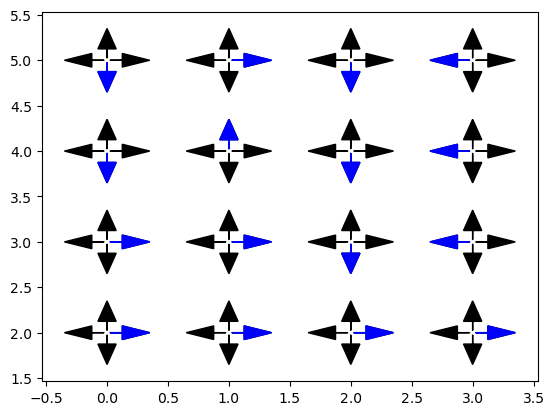

Episode   6001 | epsilon=0.994 | avg_return(last 2000)=0.016
6.352932223030613e-102 0.9999935198871485


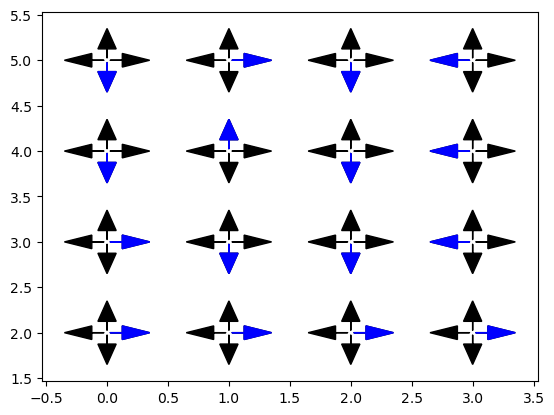

Episode   7001 | epsilon=0.993 | avg_return(last 2000)=0.017
1.882404083000493e-115 0.9999987830643808


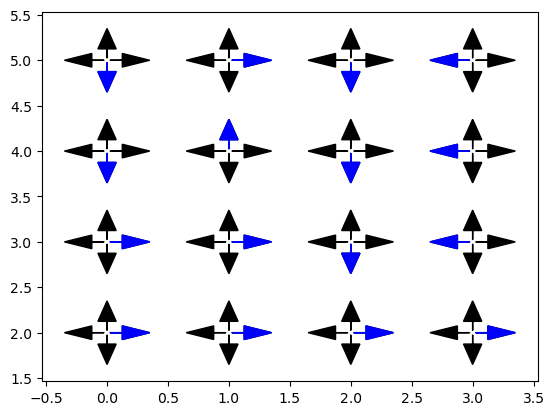

Episode   8001 | epsilon=0.992 | avg_return(last 2000)=0.016
9.712735217604617e-129 0.9999996141051734


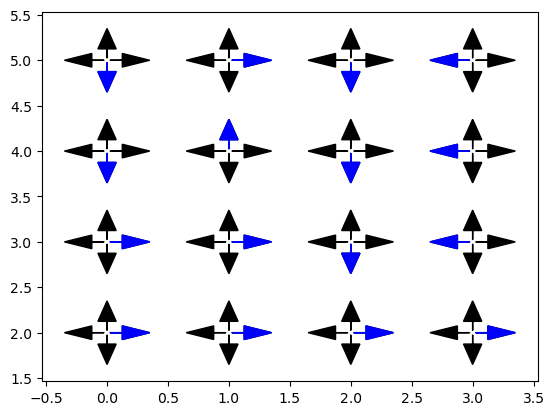

Episode   9001 | epsilon=0.991 | avg_return(last 2000)=0.011


In [15]:
Q = train_q_learning(is_slippery=slip)


In [16]:
evaluate_greedy(Q, is_slippery=slip)

1 4
1 8
2 9
1 13
2 14
2 15
Eval finished | steps=6 | total_reward=1.0


In [18]:
Q[4]

array([9.50989750e-001, 9.60595735e-001, 1.21824474e-140, 9.41479851e-001])

# Fancy Model Continuous Space Actor-Critic 

In [19]:
import gymnasium as gym

from stable_baselines3 import A2C

env = gym.make("CartPole-v1", render_mode="rgb_array")

model = A2C("MlpPolicy", env, verbose=1)
model.learn(total_timesteps=10_000)



ModuleNotFoundError: No module named 'stable_baselines3'

In [40]:
import pygame
vec_env = model.get_env()
obs = vec_env.reset()
vec_env.render("human")

for i in range(100):
    action, _state = model.predict(obs, deterministic=True)
    obs, reward, done, info = vec_env.step(action)
    vec_env.render("human")

    # VecEnv resets automatically
    # if done:
    #   obs = vec_env.reset()

In [38]:
info


{}